In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Path to images and meta
image_dir = "/kaggle/input/food41/images"
meta_dir = "/kaggle/input/food41/meta"

# Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])    # ImageNet std
])

# Create full dataset to map class_to_idx
full_dataset = datasets.ImageFolder(image_dir, transform=transform)
class_to_idx = full_dataset.class_to_idx

In [3]:
def get_paths_labels(meta_file, class_to_idx, base_dir):
    with open(meta_file, 'r') as f:
        lines = f.read().splitlines()
    paths = [os.path.join(base_dir, line + ".jpg") for line in lines]
    labels = [class_to_idx[line.split('/')[0]] for line in lines]
    return list(zip(paths, labels))

train_paths = get_paths_labels("/kaggle/input/food41/meta/meta/train.txt", class_to_idx, image_dir)
test_paths = get_paths_labels("/kaggle/input/food41/meta/meta/test.txt", class_to_idx, image_dir)


In [4]:
from PIL import Image
import torch

class FoodDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __getitem__(self, index):
        path, label = self.data[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.data)

train_data = FoodDataset(train_paths, transform=transform)
test_data = FoodDataset(test_paths, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True,num_workers=8,pin_memory=True,persistent_workers=True)

test_loader = DataLoader(test_data, batch_size=64, shuffle=False,num_workers=8,pin_memory=True,persistent_workers=True)



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False):
        super().__init__()
        stride = 2 if downsample else 1

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection
        self.downsample = downsample
        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return F.relu(out)


In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=101):
        super().__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, downsample=True),
            ResidualBlock(128, 128)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, downsample=True),
            ResidualBlock(256, 256)
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, downsample=True),
            ResidualBlock(512, 512)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses, train_accuracies = [], []

for epoch in range(25):
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}")


Epoch 1: Loss=4.0834, Acc=0.0919
Epoch 2: Loss=3.4138, Acc=0.1964
Epoch 3: Loss=2.9989, Acc=0.2729
Epoch 4: Loss=2.6725, Acc=0.3409
Epoch 5: Loss=2.3688, Acc=0.4068
Epoch 6: Loss=2.0705, Acc=0.4660
Epoch 7: Loss=1.7478, Acc=0.5436
Epoch 8: Loss=1.3965, Acc=0.6261
Epoch 9: Loss=1.0622, Acc=0.7108
Epoch 10: Loss=0.7592, Acc=0.7907
Epoch 11: Loss=0.5454, Acc=0.8471
Epoch 12: Loss=0.4121, Acc=0.8832
Epoch 13: Loss=0.3280, Acc=0.9058
Epoch 14: Loss=0.2726, Acc=0.9220
Epoch 15: Loss=0.2560, Acc=0.9244
Epoch 16: Loss=0.2184, Acc=0.9341
Epoch 17: Loss=0.2115, Acc=0.9359
Epoch 18: Loss=0.1960, Acc=0.9404
Epoch 19: Loss=0.1743, Acc=0.9472
Epoch 20: Loss=0.1716, Acc=0.9470
Epoch 21: Loss=0.1563, Acc=0.9531
Epoch 22: Loss=0.1520, Acc=0.9533
Epoch 23: Loss=0.1535, Acc=0.9526
Epoch 24: Loss=0.1368, Acc=0.9577
Epoch 25: Loss=0.1332, Acc=0.9587


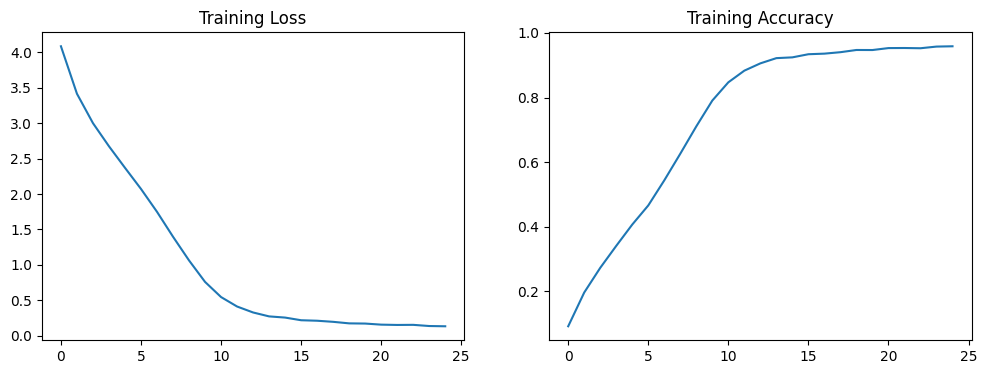

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.title('Training Accuracy')
plt.show()


In [9]:
with open("cnn_model_weights.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)


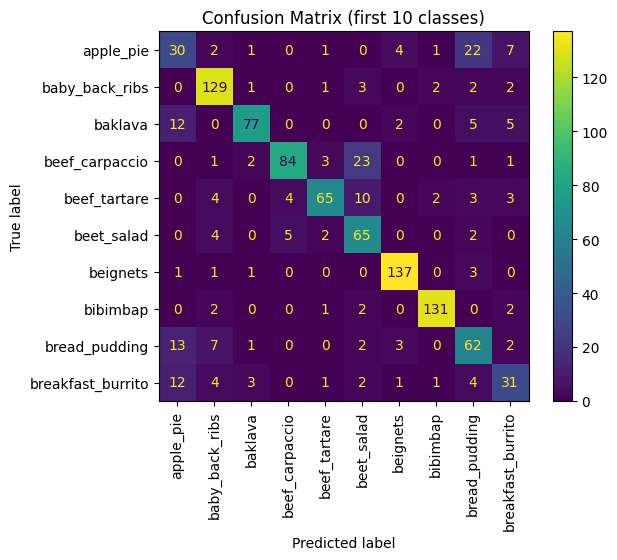

In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.topk(outputs, 5, dim=1)
        all_preds.extend(preds[:, 0].cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix for first 10 classes
cm = confusion_matrix(all_labels, all_preds, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes[:10])
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix (first 10 classes)")
plt.show()
